<a href="https://colab.research.google.com/github/vijenifer123-svg/BTVN-AI-CHIEU-THU-2/blob/main/BTVNtu%E1%BA%A7nth%E1%BB%A92.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Giá vé dự kiến: 50.00000000000012
Điểm thưởng: 59.99999999999989


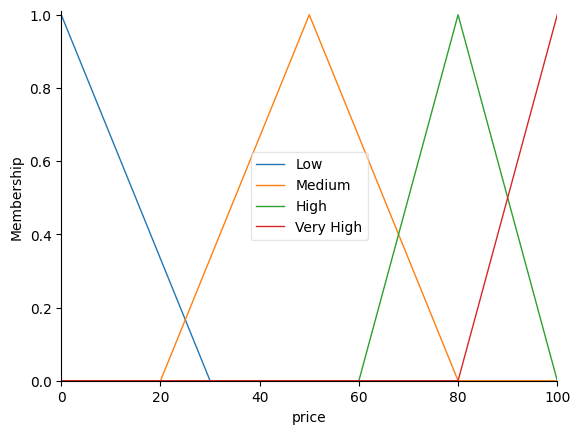

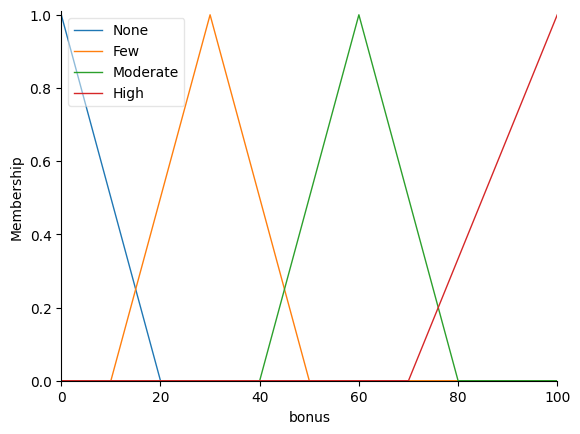

In [ ]:
#tình huống 2.11
!pip install scikit-fuzzy
import skfuzzy as fuzz
import numpy as np
from skfuzzy import control as ctrl
distance=ctrl.Antecedent(np.arange(0,50.1,0.1),'distance')
trafficcondition=ctrl.Antecedent(np.arange(0,100.1,0.1),'trafficcondition')
demandlevel=ctrl.Antecedent(np.arange(0,100.1,0.1),'demandlevel')
weathercondition=ctrl.Antecedent(np.arange(0,10.1,0.1),'weathercondition')
customerrating=ctrl.Antecedent(np.arange(0,5.1,0.1),'customerrating')
ridePunctuality=ctrl.Antecedent(np.arange(0,100.1,0.1),'ridePunctuality')

price = ctrl.Consequent(np.arange(0, 100.1, 0.1), 'price')
bonus = ctrl.Consequent(np.arange(0, 100.1, 0.1), 'bonus')

distance['Short']=fuzz.trimf(distance.universe,[0,0,3])
distance['Medium']=fuzz.trimf(distance.universe,[2,5,8])
distance['Long']=fuzz.trimf(distance.universe,[6,13,20])
distance['Very Long']=fuzz.trimf(distance.universe,[15,50,50])

trafficcondition['Low'] = fuzz.trimf(trafficcondition.universe, [0, 0, 30])
trafficcondition['Medium'] = fuzz.trimf(trafficcondition.universe, [20, 45, 70])
trafficcondition['High'] = fuzz.trimf(trafficcondition.universe, [60, 100, 100])

demandlevel['Low'] = fuzz.trimf(demandlevel.universe, [0, 0, 30])
demandlevel['Medium'] = fuzz.trimf(demandlevel.universe, [20, 45, 70])
demandlevel['High'] = fuzz.trimf(demandlevel.universe, [60, 100, 100])

weathercondition['Good'] = fuzz.trimf(weathercondition.universe, [0, 0, 4])
weathercondition['Moderate'] = fuzz.trimf(weathercondition.universe, [2, 5, 8])
weathercondition['Bad'] = fuzz.trimf(weathercondition.universe, [6, 10, 10])

customerrating['Poor'] = fuzz.trimf(customerrating.universe, [0, 1.0, 2.5])
customerrating['Average'] = fuzz.trimf(customerrating.universe, [2.0, 3.0, 4.0])
customerrating['Good'] = fuzz.trimf(customerrating.universe, [3.5, 5.0, 5.0])

ridePunctuality['Late'] = fuzz.trimf(ridePunctuality.universe, [0, 0, 50])
ridePunctuality['On Time'] = fuzz.trimf(ridePunctuality.universe, [40, 60, 80])
ridePunctuality['Early'] = fuzz.trimf(ridePunctuality.universe, [70, 100, 100])

price['Low'] = fuzz.trimf(price.universe, [0, 0, 30])
price['Medium'] = fuzz.trimf(price.universe, [20, 50, 80])
price['High'] = fuzz.trimf(price.universe, [60, 80, 100])
price['Very High'] = fuzz.trimf(price.universe, [80, 100, 100])

bonus['None'] = fuzz.trimf(bonus.universe, [0, 0, 20])
bonus['Few'] = fuzz.trimf(bonus.universe, [10, 30, 50])
bonus['Moderate'] = fuzz.trimf(bonus.universe, [40, 60, 80])
bonus['High'] = fuzz.trimf(bonus.universe, [70, 100, 100])

rule1 = ctrl.Rule(distance['Short'] & trafficcondition['Low'] & demandlevel['Low'], price['Low'])
rule2 = ctrl.Rule(distance['Short'] & trafficcondition['Medium'] & demandlevel['High'], price['Medium'])
rule3 = ctrl.Rule(distance['Medium'] & trafficcondition['High'] & demandlevel['High'], price['High'])
rule4 = ctrl.Rule(distance['Long'] & trafficcondition['Medium'] & weathercondition['Good'], price['Medium'])
rule5 = ctrl.Rule(distance['Long'] & trafficcondition['High'] & weathercondition['Bad'], price['Very High'])
rule6 = ctrl.Rule(distance['Very Long'] & trafficcondition['High'] & demandlevel['High'], price['Very High'])
rule7 = ctrl.Rule(distance['Medium'] & trafficcondition['Low'] & demandlevel['Low'], price['Medium'])
rule8 = ctrl.Rule(distance['Short'] & trafficcondition['High'] & weathercondition['Bad'], price['High'])
rule9 = ctrl.Rule(distance['Very Long'] & weathercondition['Bad'], price['Very High'])
rule10 = ctrl.Rule(distance['Medium'] & trafficcondition['Medium'] & weathercondition['Moderate'], price['Medium'])

rule11 = ctrl.Rule(customerrating['Good'] & ridePunctuality['Early'], bonus['High'])
rule12 = ctrl.Rule(customerrating['Average'] & ridePunctuality['On Time'], bonus['Moderate'])
rule13 = ctrl.Rule(customerrating['Poor'] & ridePunctuality['Late'], bonus['None'])
rule14 = ctrl.Rule(distance['Long'] & trafficcondition['High'] & ridePunctuality['On Time'], bonus['High'])
rule15 = ctrl.Rule(distance['Medium'] & trafficcondition['Medium'] & customerrating['Good'], bonus['Moderate'])
rule16 = ctrl.Rule(customerrating['Poor'] & ridePunctuality['Late'], bonus['None'])
rule17 = ctrl.Rule(distance['Very Long'] & weathercondition['Bad'] & customerrating['Good'], bonus['High'])
rule18 = ctrl.Rule(distance['Short'] & customerrating['Average'] & ridePunctuality['On Time'], bonus['Few'])
rule19 = ctrl.Rule(distance['Long'] & trafficcondition['High'] & ridePunctuality['Late'], bonus['Few'])
rule20 = ctrl.Rule(distance['Medium'] & weathercondition['Moderate'] & customerrating['Good'], bonus['Moderate'])

ride_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8, rule9, rule10,
                                rule11, rule12, rule13, rule14, rule15, rule16, rule17, rule18, rule19, rule20])

ride_sim=ctrl.ControlSystemSimulation(ride_ctrl)

ride_sim.input['distance'] = 5
ride_sim.input['trafficcondition'] = 50
ride_sim.input['demandlevel'] = 50
ride_sim.input['weathercondition'] = 7
ride_sim.input['customerrating'] = 4
ride_sim.input['ridePunctuality'] = 60

ride_sim.compute()
print("Giá vé dự kiến:", ride_sim.output['price'])
print("Điểm thưởng:", ride_sim.output['bonus'])
price.view()
bonus.view()

Mức chiết khấu đề xuất: 55.00%


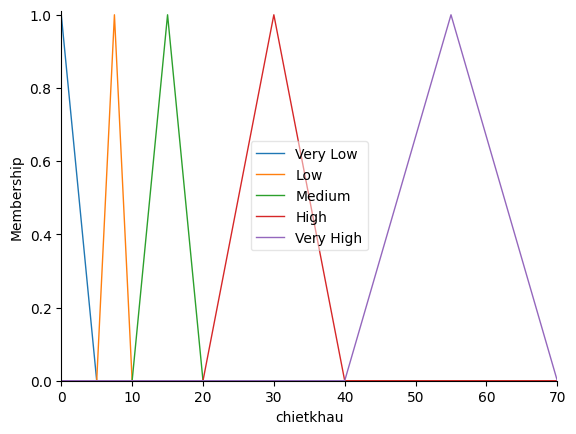

In [ ]:
!pip install scikit-fuzzy
import skfuzzy as fuzz
import numpy as np
from skfuzzy import control as ctrl


store_rating = ctrl.Antecedent(np.arange(0, 5.1, 0.1), 'Store Rating')
sales_volume = ctrl.Antecedent(np.arange(0, 100.1, 0.1), 'Sales Volume')
profit_margin = ctrl.Antecedent(np.arange(10, 20.1, 0.1), 'Profit Margin')
season_event = ctrl.Antecedent(np.arange(0, 5.1, 0.1), 'Season Event')
competitor_discounts = ctrl.Antecedent(np.arange(0, 10.1, 0.1), 'Competitor Discounts')

chietkhau = ctrl.Consequent(np.arange(0, 70.1, 0.1), 'chietkhau')


store_rating['Low'] = fuzz.trimf(store_rating.universe, [0, 0, 3.9])
store_rating['Medium'] = fuzz.trimf(store_rating.universe, [4, 4.25, 4.5])
store_rating['High'] = fuzz.trimf(store_rating.universe, [4.6, 4.8, 5])

sales_volume['Low'] = fuzz.trimf(sales_volume.universe, [0, 0, 50])
sales_volume['Medium'] = fuzz.trimf(sales_volume.universe, [40, 50, 60])
sales_volume['High'] = fuzz.trimf(sales_volume.universe, [55, 100, 100])

profit_margin['Low'] = fuzz.trimf(profit_margin.universe, [10, 10, 15])
profit_margin['Medium'] = fuzz.trimf(profit_margin.universe, [13, 15, 17])
profit_margin['High'] = fuzz.trimf(profit_margin.universe, [16, 20, 20])


season_event['None'] = fuzz.trimf(season_event.universe, [0, 0, 2])
season_event['Moderate'] = fuzz.trimf(season_event.universe, [1, 2, 3])
season_event['High'] = fuzz.trimf(season_event.universe, [2.5, 5, 5])

competitor_discounts['Low'] = fuzz.trimf(competitor_discounts.universe, [0, 0, 5])
competitor_discounts['Medium'] = fuzz.trimf(competitor_discounts.universe, [3, 5, 7])
competitor_discounts['High'] = fuzz.trimf(competitor_discounts.universe, [6, 10, 10])

chietkhau['Very Low'] = fuzz.trimf(chietkhau.universe, [0, 0, 5])
chietkhau['Low'] = fuzz.trimf(chietkhau.universe, [5, 7.5, 10])
chietkhau['Medium'] = fuzz.trimf(chietkhau.universe, [10, 15, 20])
chietkhau['High'] = fuzz.trimf(chietkhau.universe, [20, 30, 40])
chietkhau['Very High'] = fuzz.trimf(chietkhau.universe, [40, 55, 70])


rule1 = ctrl.Rule(store_rating['High'] & sales_volume['High'] & profit_margin['High'], chietkhau['Very Low'])
rule2 = ctrl.Rule(store_rating['Low'] & sales_volume['Low'] & profit_margin['High'], chietkhau['High'])
rule3 = ctrl.Rule(season_event['High'] & competitor_discounts['High'], chietkhau['Very High'])
rule4 = ctrl.Rule(store_rating['Medium'] & sales_volume['Medium'] & profit_margin['Medium'], chietkhau['Medium'])
rule5 = ctrl.Rule(competitor_discounts['Low'] & profit_margin['Low'] & sales_volume['High'], chietkhau['Very Low'])
rule6 = ctrl.Rule(store_rating['Low'] & season_event['None'], chietkhau['Medium'])
rule7 = ctrl.Rule(sales_volume['Low'] & profit_margin['Low'], chietkhau['Very High'])

discount_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7])
discount=ctrl.ControlSystemSimulation(discount_ctrl)

discount.input['Store Rating']=4.3
discount.input['Sales Volume']=50
discount.input['Profit Margin']=13
discount.input['Season Event']=4
discount.input['Competitor Discounts']=8

discount.compute()

print(f"Mức chiết khấu đề xuất: {discount.output['chietkhau']:.2f}%")
chietkhau.view()

Mức chiết khấu đề xuất cho cửa hàng là: 15.00%


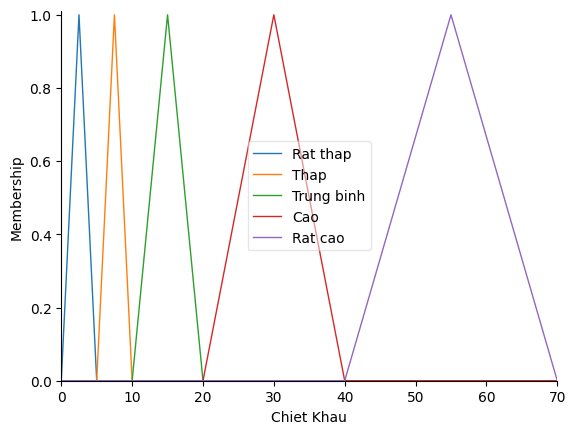

In [ ]:
#tình huốn 2.13
!pip install scikit-fuzzy
import skfuzzy as fuzz
import numpy as np
from skfuzzy import control as ctrl

product_demand = ctrl.Antecedent(np.arange(0, 10.1, 0.1), 'Product Demand')
pricing_pressure = ctrl.Antecedent(np.arange(0, 10.1, 0.1), 'Pricing Pressure')
seasonal_demand = ctrl.Antecedent(np.arange(0, 10.1, 0.1), 'Seasonal Demand')
store_reputation = ctrl.Antecedent(np.arange(0, 5.1, 0.1), 'Store Reputation')
profit_margin = ctrl.Antecedent(np.arange(0, 50.1, 0.1), 'Profit Margin')

chiet_khau = ctrl.Consequent(np.arange(0, 70.1, 0.1), 'Chiet Khau')

product_demand['Thap'] = fuzz.trimf(product_demand.universe, [0, 0, 5])
product_demand['Trung binh'] = fuzz.trimf(product_demand.universe, [3, 5, 7])
product_demand['Cao'] = fuzz.trimf(product_demand.universe, [5, 10, 10])

pricing_pressure['Thap'] = fuzz.trimf(pricing_pressure.universe, [0, 0, 5])
pricing_pressure['Trung binh'] = fuzz.trimf(pricing_pressure.universe, [3, 5, 7])
pricing_pressure['Cao'] = fuzz.trimf(pricing_pressure.universe, [5, 10, 10])

seasonal_demand['Khong co'] = fuzz.trimf(seasonal_demand.universe, [0, 0, 2])
seasonal_demand['Trung binh'] = fuzz.trimf(seasonal_demand.universe, [1, 5, 8])
seasonal_demand['Cao'] = fuzz.trimf(seasonal_demand.universe, [7, 10, 10])


store_reputation['Thap'] = fuzz.trimf(store_reputation.universe, [0, 0, 3.9])
store_reputation['Trung binh'] = fuzz.trimf(store_reputation.universe, [4.0, 4.25, 4.5])
store_reputation['Cao'] = fuzz.trimf(store_reputation.universe, [4.6, 5.0, 5.0])

profit_margin['Thap'] = fuzz.trimf(profit_margin.universe, [0, 0, 15])
profit_margin['Trung binh'] = fuzz.trimf(profit_margin.universe, [10, 20, 30])
profit_margin['Cao'] = fuzz.trimf(profit_margin.universe, [25, 50, 50])

chiet_khau['Rat thap'] = fuzz.trimf(chiet_khau.universe, [0, 2.5, 5])
chiet_khau['Thap'] = fuzz.trimf(chiet_khau.universe, [5, 7.5, 10])
chiet_khau['Trung binh'] = fuzz.trimf(chiet_khau.universe, [10, 15, 20])
chiet_khau['Cao'] = fuzz.trimf(chiet_khau.universe, [20, 30, 40])
chiet_khau['Rat cao'] = fuzz.trimf(chiet_khau.universe, [40, 55, 70])

rule1 = ctrl.Rule(product_demand['Cao'] & pricing_pressure['Thap'] & profit_margin['Thap'], chiet_khau['Rat thap'])
rule2 = ctrl.Rule(product_demand['Thap'] & pricing_pressure['Cao'] & profit_margin['Cao'], chiet_khau['Cao'])
rule3 = ctrl.Rule(store_reputation['Cao'] & profit_margin['Trung binh'] & seasonal_demand['Cao'], chiet_khau['Trung binh'])
rule4 = ctrl.Rule(pricing_pressure['Cao'] & seasonal_demand['Cao'] & profit_margin['Cao'], chiet_khau['Rat cao'])
rule5 = ctrl.Rule(store_reputation['Thap'] & product_demand['Trung binh'] & profit_margin['Thap'], chiet_khau['Trung binh'])
rule6 = ctrl.Rule(product_demand['Cao'] & seasonal_demand['Khong co'] & pricing_pressure['Thap'], chiet_khau['Rat thap'])
rule7 = ctrl.Rule(profit_margin['Cao'] & pricing_pressure['Trung binh'] & seasonal_demand['Cao'], chiet_khau['Trung binh'])

discount_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7])
discount_simulator = ctrl.ControlSystemSimulation(discount_ctrl)


discount_simulator.input['Product Demand'] = 9.0
discount_simulator.input['Pricing Pressure'] = 5.0
discount_simulator.input['Store Reputation'] = 4.2
discount_simulator.input['Profit Margin'] = 40.0
discount_simulator.input['Seasonal Demand'] = 9.0

discount_simulator.compute()

print(f"Mức chiết khấu đề xuất cho cửa hàng là: {discount_simulator.output['Chiet Khau']:.2f}%")
chiet_khau.view()

Điểm số lượng đơn hàng cần kết hợp: 8.19/10
Điểm mức độ ưu tiên giao hàng:      5.00/10


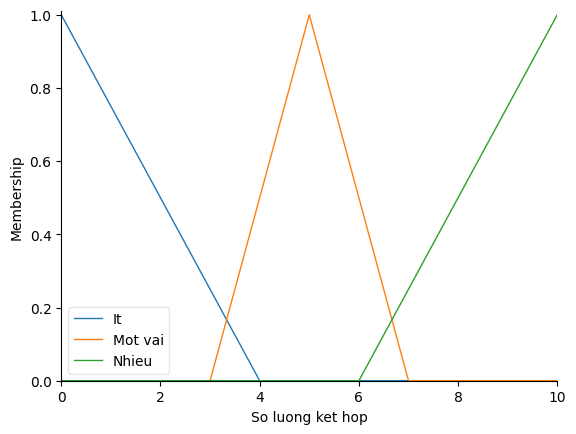

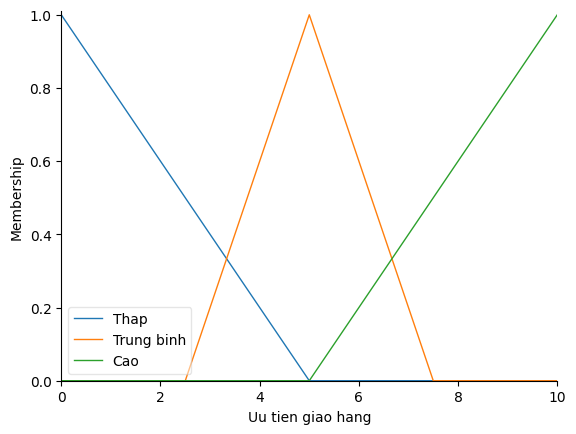

In [ ]:
#tinh huong 2.14
!pip install scikit-fuzzy
import skfuzzy as fuzz
import numpy as np
from skfuzzy import control as ctrl

mat_do = ctrl.Antecedent(np.arange(0, 10.1, 0.1), 'Mat do don hang')
khan_cap = ctrl.Antecedent(np.arange(0, 10.1, 0.1), 'Muc do khan cap')
tai_trong = ctrl.Antecedent(np.arange(0, 10.1, 0.1), 'Tai trong')
giao_thong = ctrl.Antecedent(np.arange(0, 10.1, 0.1), 'Giao thong')
loi_nhuan = ctrl.Antecedent(np.arange(0, 10.1, 0.1), 'Loi nhuan')

ket_hop = ctrl.Consequent(np.arange(0, 10.1, 0.1), 'So luong ket hop')
uu_tien = ctrl.Consequent(np.arange(0, 10.1, 0.1), 'Uu tien giao hang')

for x in [mat_do, khan_cap, tai_trong, giao_thong, loi_nhuan, uu_tien]:
    x['Thap'] = fuzz.trimf(x.universe, [0, 0, 5])
    x['Trung binh'] = fuzz.trimf(x.universe, [2.5, 5, 7.5])
    x['Cao'] = fuzz.trimf(x.universe, [5, 10, 10])

ket_hop['It'] = fuzz.trimf(ket_hop.universe, [0, 0, 4])
ket_hop['Mot vai'] = fuzz.trimf(ket_hop.universe, [3, 5, 7])
ket_hop['Nhieu'] = fuzz.trimf(ket_hop.universe, [6, 10, 10])

rule1 = ctrl.Rule(mat_do['Cao'] & tai_trong['Thap'] & giao_thong['Thap'], ket_hop['Nhieu'])
rule2 = ctrl.Rule(mat_do['Trung binh'] & giao_thong['Cao'] & khan_cap['Trung binh'], ket_hop['Mot vai'])
rule3 = ctrl.Rule(tai_trong['Cao'] & mat_do['Cao'] & loi_nhuan['Trung binh'], ket_hop['Mot vai'])
rule4 = ctrl.Rule(mat_do['Thap'] & khan_cap['Cao'] & giao_thong['Trung binh'], ket_hop['Mot vai'])
rule5 = ctrl.Rule(loi_nhuan['Cao'] & khan_cap['Cao'] & giao_thong['Cao'], ket_hop['Mot vai'])
rule6 = ctrl.Rule(khan_cap['Cao'] & loi_nhuan['Cao'], uu_tien['Cao'])
rule7 = ctrl.Rule(khan_cap['Trung binh'] & giao_thong['Trung binh'], uu_tien['Trung binh'])
rule8 = ctrl.Rule(khan_cap['Thap'] & mat_do['Cao'] & loi_nhuan['Thap'], uu_tien['Thap'])

logistics_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8])
logistics_sim = ctrl.ControlSystemSimulation(logistics_ctrl)

logistics_sim.input['Mat do don hang'] = 8.5
logistics_sim.input['Muc do khan cap'] = 5.0
logistics_sim.input['Tai trong'] = 2.0
logistics_sim.input['Giao thong'] = 4.0
logistics_sim.input['Loi nhuan'] = 5.0

logistics_sim.compute()

print(f"Điểm số lượng đơn hàng cần kết hợp: {logistics_sim.output['So luong ket hop']:.2f}/10")
print(f"Điểm mức độ ưu tiên giao hàng:      {logistics_sim.output['Uu tien giao hang']:.2f}/10")

ket_hop.view()
uu_tien.view()